# Logistinen regressio malli 2
Rakenne sama kuin Malli 1:ssä, ilman pitkäaikaissokeria
vertaillaan tuloksia mallien välillä

## 1. Kirjastot ja data

Ladataan tarvittavat kirjastot ja luetaan aineisto sisään.

In [47]:
#!pip install statsmodels

In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import statsmodels.api as sm

In [49]:
df=pd.read_csv("database_original.csv")

In [50]:
df.drop(columns=['Pitkaaikaissokeri','HDL', 'Insuliini', 'Kokonaiskolesteroli','BMI', 'Vyotaronymparys','Reipas_liikunta(pv/vk)', 'Kavely(pv/vk)'], inplace=True) #lisätään poistettuihin muuutjiin pitkäaikasisokeri 

## 2. Datan valmistelu

Osa muuttujista pudotetaan pois mallista korrelaatiomatriisin ja VIF-analyysin perusteella.
Korrelaatiomatriisin avulla tutkitaan muuttujien välisten 
lineaaristen yhteyksien voimakkuutta ja suuntaa. Arvot 
vaihtelevat välillä -1 ja 1:
Sininen -kuvaa positiivista korrelaatiota — mitä tummempi, sitä voimakkaampi yhteys
Punainen: -kuvaa negatiivista korrelaatiota — mitä tummempi, sitä voimakkaampi käänteinen yhteys
Valkoinen -tarkoittaa että lineaarista yhteyttä ei ole

VIF-analyysi tunnistaa monimuuttuja-multikollineaarisuuden. 
Kynnysarvona pidetään VIF > 10 — sen ylittävät muuttujat tulisi poistetaan 
Diabetes jätetään VIF-analyysin ulkopuolelle, koska se on selitettävä muuttuja.

In [51]:
corr_matrix =df.corr()

<Axes: >

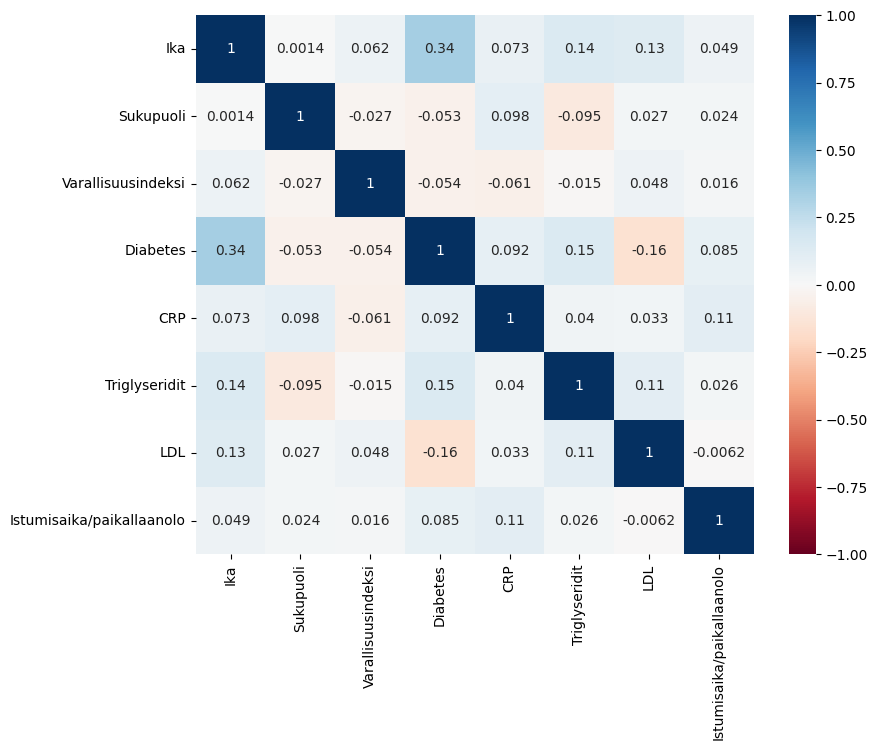

In [52]:
plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, vmin = -1.0, vmax = 1.0, cmap ='RdBu', annot = True)

Tarkastellaan merkittävimpien muuttujien välisiä korrelaatioita, osa muutujista poistettu mallista:
-diabetes ja ikä (r=0.34)
Muut muutujat korreloivat keskenään heikosti (-0.16-0.15)
Vaikka iän korrelaatio selitettävän muutujan (diabetes) kanssa on selvästi mekittävä, se ei välttämättä aiheuta multikollinearisuus ongelmaa, vaan se oikeasti selittää selitettävää muutujaa. 

Korrelaatiomatriisi tunnistaa muuttujien väliset parit, mutta 
ei kerro kokonaiskuvaa multikollinearisuudesta muutujien välillä — siksi 
tarkastellaan lisäksi vielä VIF-analyysia.

In [53]:
X_vif = df.drop("Diabetes", axis=1)
X_vif = pd.get_dummies(X_vif, drop_first=True)

vif_df = pd.DataFrame()
vif_df["Variables"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                 for i in range(X_vif.shape[1])]
vif_df

,Variables,VIF
0,Ika,5.711707
1,Sukupuoli,6.752922
2,Varallisuusindeksi,4.736921
3,CRP,1.351876
4,Triglyseridit,2.182696
5,LDL,7.843116
6,Istumisaika/paikallaanolo,1.423032





Pitkäaikaissokerin poistamisen jälkeen kaikki VIF-arvot ovat 
alle 10, mikä viittaa siihen, että aiemmin tunnistettu merkittävä kollinearisuus on halinnassa tällä muuttuja valinnalla. kaikki arvotkin ovat jo selvästi lähempänä  arvoa 5 eli hyväksyttävän arvon ylärajaa, kuin mallissa 1. sekä kaikki muuttujat pysvät selvästi alle 10 kriitisen kynnyksen.

In [54]:
y = df["Diabetes"] #selitettävä muuttuja
X = df.drop("Diabetes", axis=1) #selittävät muuttujat
X = pd.get_dummies(X, drop_first=True)

In [55]:
X_train, X_test, y_train, y_test =train_test_split( X, y, test_size=0.2, random_state = 42)

In [56]:
scaler = RobustScaler() #skaalataan muutujat RobustScaler-menetelmällä, joka sietää paremmin aineiston poikkeavia havaintoja verattuna standardScaleriin
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(2472, 7)
(618, 7)
(2472,)
(618,)


In [57]:
y_train.value_counts().round(2)

Diabetes
0    2115
1     357
Name: count, dtype: int64

In [58]:
y_test.value_counts().round(2)


Diabetes
0    538
1     80
Name: count, dtype: int64

## 3. Mallin rakentaminen

Rakennetaan toinen logistinen regressiomalli samoilla muuttujilla kuin ensimmäisessä mallissa poislukien poislukien pitkäaikaissokeri, joka poistetaan tietovuodon 
välttämiseksi — HbA1c on diagnostinen kriteeri diabetekselle. Aineistossa on luokkaimbalanssi: 86% ei-diabeetikkoja ja 14% diabeetikkoja. Tämä korjataan käyttämällä class_weight='balanced' logistisessa regressiossa, jotta malli ei yliopi ennustamaan pelkästään ei-diabeetikkoja.

In [59]:
model = LogisticRegression(solver='liblinear', class_weight='balanced', max_iter=1000)
 #class_weight 'balanced '-> epätasaisessa datassa antaa enemmän painoa harvinaiselle luokalle eli tässä aineistossa diabetekselle , jota ennustetaan
 #max_iter -> määrittää, kunka monta iteraatiota logistinen regressio saa käyttää ratkaisun tekemiseen
model.fit(X_train_scaled, y_train) 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Logistinen regressiomalli sovitetaan skaalattuun harjoitusaineistoon. Parametrina käytetään class_weight='balanced', joka antaa enemmän painoarvoa harvinaiselle lokalle eli diabetekselle. max_iter = 1000 varmistaa, että malli ehtii konvergoitua.

In [60]:
print('intercept:', model.intercept_) #Intercept on mallin vakiotermi — se kuvaa diabeteksen perustodennäköisyyttä kun kaikki selittäjät ovat nolla.
print('Coefficient:', model.coef_) # Koeffisientit kertovat kunkin muuttujan vaikutuksen suunnan ja voimakkuuden diabeteksen ennustamiseen, kun muut muuttujat pidetään vakioina:
print()
coef_df = pd.DataFrame({
    'Muuttuja': X.columns,
    'Kerroin': model.coef_[0]
}).sort_values('Kerroin', ascending=False)
print(coef_df) 


intercept: [-0.83037115]
Coefficient: [[ 2.34833806 -0.16618024 -0.43259734  0.10014362  0.37543875 -0.64831894
   0.05390911]]

                    Muuttuja   Kerroin
0                        Ika  2.348338
4              Triglyseridit  0.375439
3                        CRP  0.100144
6  Istumisaika/paikallaanolo  0.053909
1                  Sukupuoli -0.166180
2         Varallisuusindeksi -0.432597
5                        LDL -0.648319


Pitkäaiakaissokerin poistamisen jälkeen kertoimien perusteella ikä on vahvimmin diabeteksen riskitekijänä. Triglyseridit ja CRP lisäävät hieman riskiä. LDL, varallisuusindeksi ja sukupuoli vähentävät diabeteksen riskiä edellen hieman. Intercept kuvaa diabeteksen perustodennäköisyyttä, kun kaikki muuttujat ovat nolla. Perustodennäköisyys kasvoi hiukan -2,21 -> 0.83 eli mallista on lähtenyt selitysvoimaa ja se joutuu arvelemaan enemmän tulosta, joka näkyy mallin arviointi osiossa 4. myös loglossin kasvuna malli 1 verrattuna.

## 4. Mallin arviointi

Arvioidaan mallin suorituskyky testidatalla. Koska aineistossa on 
luokkaimbalanssi, pelkkä tarkkuus (accuracy) ei riitä — tarkastellaan 
myös ROC-AUC, confusion matrix ja classification report. ROC-AUC kertoo kuinka hyvin malli erottaa diabeteksen ei diabeteksestä:

### 4.1 Ennustetut todennäköisyydet ja jakauma

In [61]:
#ennusteet: binaarinen ja jatkuva -tarvitaan mallin arvioinnissa alempana
Y_pred_probabilities = model.predict_proba(X_test_scaled)[:,1] # todennäköisyydet (0.0–1.0) -> käytetään ROC-käyrässä ja AUC:ssa
y_pred = model.predict(X_test_scaled) # binääriset ennusteet (0 tai 1) -> käytetään confusion matrixissa ja classification reportissa
Y_pred_probabilities

array([0.42713875, 0.05199482, 0.40378139, 0.47110966, 0.10188689,
       0.06438802, 0.21387991, 0.07162076, 0.22301591, 0.84438607,
       0.75104385, 0.04570553, 0.20738003, 0.80469089, 0.0754878 ,
       0.78850297, 0.96678212, 0.43239629, 0.06832591, 0.62071329,
       0.07956957, 0.74854647, 0.73792352, 0.08377733, 0.16764478,
       0.18496483, 0.18837428, 0.8771837 , 0.85273779, 0.46394832,
       0.11842962, 0.17240782, 0.64424199, 0.13789164, 0.04485432,
       0.1600573 , 0.09809185, 0.21780816, 0.70394459, 0.06966403,
       0.18163061, 0.07941315, 0.34959758, 0.41590066, 0.07276018,
       0.56574821, 0.12941094, 0.16112253, 0.92064206, 0.49962162,
       0.80050532, 0.30867871, 0.95587714, 0.56493538, 0.20728948,
       0.90828037, 0.8052062 , 0.88258861, 0.23936148, 0.77133983,
       0.0946975 , 0.03437819, 0.13286746, 0.55450501, 0.55793306,
       0.13559618, 0.18868621, 0.13298034, 0.34660394, 0.70409942,
       0.59441675, 0.67932847, 0.18153967, 0.08121775, 0.38256

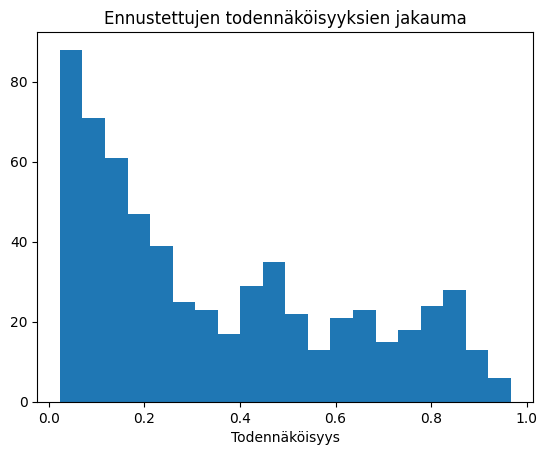

In [62]:
plt.hist(Y_pred_probabilities, bins=20)
plt.xlabel('Todennäköisyys')
plt.title('Ennustettujen todennäköisyyksien jakauma')
plt.show()

Jakauma laskee tasaisesti vasemmalta oikealle ilman selkeää 
toista huippua lähellä ykköstä. Arvoja löytyy tasaisemmin 
koko väliltä 0.0–1.0, mikä kertoo että ilman pitkäaikaissokeria 
malli on epävarmempi ennusteissaan. Tämä näkyy myös 
korkeampana log lossina (0.376 vs 0.176) — malli ei pysty 
luokittelemaan henkilöitä yhtä varmuudella kuin Malli 1.

Kliinisessä seulonnassa tämä on silti hyödyllistä — malli 
tuottaa riskiryhmittelyä koko todennäköisyysasteikolla eikä 
luokittele mustavalkoisesti.

### 4.2 Log Loss
Mittaa kuinka tarkasti ja varmasti malli antaa todennäköisyyksiä.
Mitä lähempänä 0 sitä parempi:
- alle 0.3 → erinomainen
- 0.3–0.5 → hyvä
- yli 0.7 → heikko

In [63]:
logloss = log_loss(y_test, Y_pred_probabilities)
print(logloss)

0.49333773678152026


### Log Loss = 0.493
Log loss nousi 0.228 → 0.493 pitkäaikaissokerin poistamisen 
jälkeen. Malli 2 on epävarmempi todennäköisyysennusteissaan, 
mutta pysyy selvästi alle satunnaisen arvauksen tason (0.693).


### 4.3 AUC ja ROC-käyrä
ROC-käyrä kuvaa mallin erottelukykyä eri kynnysarvoilla.
AUC mittaa mallin kykyä erotella diabeetikot ei-diabeetikoista 
eri päätöskynnysarvoilla. Arvo 1.0 on täydellinen ja 0.5 
vastaa satunnaista arvausta.

- 0.9–1.0 → erinomainen
- 0.8–0.9 → hyvä  
- 0.7–0.8 → kohtalainen

In [64]:
auc = roc_auc_score(y_test, Y_pred_probabilities)
print("AUC", auc)

AUC 0.8164730483271375


### AUC = 0.816 

AUC laski 0.953 → 0.816 pitkäaikaissokerin poistamisen jälkeen, 
mikä oli odotettua. Arvo 0.816 on silti hyvä — malli järjestää
diabeteksen todennäköisemmäksi kuin ei-diabeteksestä 81.6%.

Tämä tulos vahvistaa että pitkäaikaissokeri dominoi Malli 1:n 
ennustuskykyä. Malli 2 soveltuu tilanteisiin, joissa pitkäaikaissokeria ei ole saatavilla eli 
kuinka hyvin diabetes voidaan ennustaa ilman HbA1c-mittausta 
— esimerkiksi varhaisen riskin tunnistamisessa ennen diagnoosia.

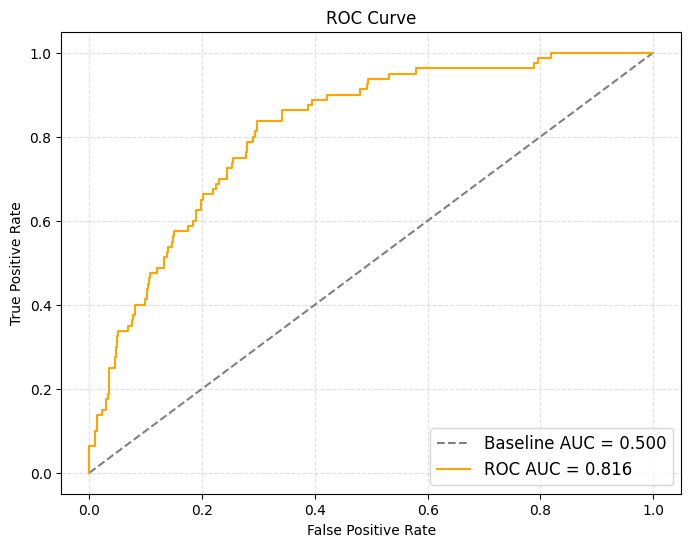

In [65]:

baseline_probs = [0 for _ in range(len(y_test))] # baseline-malli

Y_pred_probabilities = model.predict_proba(X_test_scaled)[:, 1] # mallin todennäköisyydet luokalle 1


baseline_auc = roc_auc_score(y_test, baseline_probs) # baseline AUC
pc_auc = roc_auc_score(y_test, Y_pred_probabilities) #predict_probalities AUC

# ROC-käyrän pisteet
baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_probs)
fpr, tpr, thresholds = roc_curve(y_test, Y_pred_probabilities, drop_intermediate=False)

# ROC-käyrä
plt.figure(figsize=(8,6))

plt.plot(
    baseline_fpr, baseline_tpr,
    linestyle='--', color='gray',
    label=f'Baseline AUC = {baseline_auc:.3f}'
)

plt.plot(
    fpr, tpr,
    color='orange',
    label=f'ROC AUC = {pc_auc:.3f}'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()


### ROC-käyrä ja AUC = 0.816

ROC-käyrä kuvaa mallin herkkyyttä (True Positive Rate) suhteessa 
vääriin hälytyksiin (False Positive Rate) eri kynnysarvoilla.

Käyrä nousee selvästi baseline-viivan yläpuolelle, mutta loivemmin kuin Malli 1:ssä. 
Malli kykenee silti erottamaan diabeteksen kohtuullisen ei -diabeteksestä hyvin ilmam pitkäaikaissokeria.
AUC 0.816 vahvistaa, että malli pn käyttökelpoinen vaikka ennustekyky heikkenee verattuna malli 1:een (AUC 0.953)

### 4.4 Tilastollinen tarkastelu 

In [66]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n",cm)
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy = %.3f" % (accuracy)) 
print("\nClassification report\n")
print(classification_report(y_test, y_pred))

Confusion matrix:
 [[413 125]
 [ 24  56]]

Accuracy = 0.759

Classification report

              precision    recall  f1-score   support

           0       0.95      0.77      0.85       538
           1       0.31      0.70      0.43        80

    accuracy                           0.76       618
   macro avg       0.63      0.73      0.64       618
weighted avg       0.86      0.76      0.79       618



### Confusion Matrix ja Classification Report
Malli 2 tunnistaa 70% diabeteksestä oikein (recall=0.70), mikä on 
selvästi heikompi kuin Malli 1 (recall=0.86). Precision laski merkittävästi 0.61 → 0.31, mikä tarkoittaa että 
malli tuottaa enemmän turhia hälytyksiä ilman pitkäaikaissokeria.Kokonaistarkkuus laski 0.909-> 0.759.
Kokonaisuudessaan Malli 2 on heikompi kaikilla mittareilla, mutta on käyttökelpoinen tilanteissa, joissa ei ole pitkäaikassokeria saatavilla. 


In [67]:
x_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)


In [68]:
x_train_scaled_df= x_train_scaled_df.reset_index(drop=True) #synkronoidaan 
y_train= y_train.reset_index(drop=True)

X1 = sm.add_constant(x_train_scaled_df) #lisätään vakiotermi

logreg = sm.Logit(y_train,X1).fit() #luodaan lositinen

logreg.params
print(logreg.summary())

Optimization terminated successfully.
         Current function value: 0.317740
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               Diabetes   No. Observations:                 2472
Model:                          Logit   Df Residuals:                     2464
Method:                           MLE   Df Model:                            7
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                  0.2305
Time:                        06:53:31   Log-Likelihood:                -785.45
converged:                       True   LL-Null:                       -1020.7
Covariance Type:            nonrobust   LLR p-value:                 1.769e-97
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -2.4505      0.113    -21.616      0.000      -2.


PseudoR² = 0.231 viittaa kohtalaiseen mallin sopivuuteen -selvästi heikompi kuin kuin malli1. Pitkäaikaissokerin poistamisen jälkeen usemmat muutujat nousevat merkitseviksi: ikä, triglyseridit, LDL, varallisuusindeksi ja CRP. Sukupuoli on ainut joka jää edelleen ei tilastollisesti merkitsevänä.


In [69]:
df_table = pd.DataFrame({"variable": logreg.params.index, "coef": logreg.params, "odds_ratio": np.exp(logreg.params.values), "p_value": logreg.pvalues})
print(df_table)

                                            variable      coef  odds_ratio  \
const                                          const -2.450523    0.086248   
Ika                                              Ika  2.066454    7.896770   
Sukupuoli                                  Sukupuoli -0.180518    0.834837   
Varallisuusindeksi                Varallisuusindeksi -0.412559    0.661954   
CRP                                              CRP  0.082661    1.086173   
Triglyseridit                          Triglyseridit  0.231479    1.260462   
LDL                                              LDL -0.751447    0.471683   
Istumisaika/paikallaanolo  Istumisaika/paikallaanolo  0.048778    1.049988   

                                 p_value  
const                      1.267882e-103  
Ika                         1.411846e-51  
Sukupuoli                   1.679270e-01  
Varallisuusindeksi          2.598121e-03  
CRP                         1.498358e-03  
Triglyseridit               1.384470e-0

### Odds Ratio

Tulkintasääntö:

Odds ratio > 1 → muuttuja lisää riskiä
Odds ratio = 1 → ei vaikutusta
Odds ratio  < 1 → muuttuja vähentää riskiä

Kuvaa muuttujan vaikutuksen voimakkuutta diabetesriskiin ilman pitkäaikaissokeria.
Keskeisimmät havainnot:
-Ikä (OR=7.90): vahvin riskitekijä — nousi selvästi Malli 1:stä (OR=5.99), koska ikä kompensoi pitkäaikaissokerin poistumista
-Triglyseridit (OR=1.26): kohonneet triglyseridit lisäävät riskiä 26% — ei merkitsevä Malli 1:ssä
-CRP (OR=1.09): tulehdus lisää riskiä lievästi — ei merkitsevä Malli 1:ssä
-Istumisaika (OR=1.05): istuva elämäntapa lisää riskiä lievästi
-LDL (OR=0.47): negatiivinen yhteys — vähentää iskiä tässä mallissa, mutta on ristiriitainen aikaisempien terveystutkimusten tietojen mukaan
-Varallisuusindeksi (OR=0.66): korkeampi varallisuus vähentää riskiä lievästi
-Sukupuoli (OR=0.83): ei tilastollisesti merkitsevä (p=0.168)
